In [1]:
import pandas as pd
import scipy.stats as stats
import numpy as np

import statsmodels.api as sm
from statsmodels.formula.api import ols
import patsy

import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.precision', 3)

In [3]:
df = pd.read_csv('data_housingprice_hcm.csv', low_memory=False)
df['ppa'] = df['price']/df['area']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8838 entries, 0 to 8837
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      8838 non-null   object 
 1   price      8838 non-null   float64
 2   published  8838 non-null   object 
 3   area       8838 non-null   float64
 4   address    8838 non-null   object 
 5   district   8838 non-null   object 
 6   city       8838 non-null   object 
 7   ppa        8838 non-null   float64
dtypes: float64(3), object(5)
memory usage: 552.5+ KB


In [5]:
df['district'].value_counts()

district
Quận Bình Thạnh     773
Quận Gò Vấp         619
Quận Phú Nhuận      596
Quận Tân Bình       569
Quận 3              545
Quận 10             477
Quận 5              476
Quận 4              453
Quận 8              411
Quận Tân Phú        408
Quận 11             397
Quận 9              393
Quận 1              392
Quận 12             390
Quận 7              382
Quận Bình Tân       364
Quận Thủ Đức        335
Quận 6              296
Quận 2              272
Huyện Nhà Bè        130
Huyện Bình Chánh    100
Huyện Hóc Môn        53
Huyện Củ Chi          7
Name: count, dtype: int64

In [6]:
%%time

# We remove some district with too few observations
df = df.loc[~df['district'].isin(['Huyện Hóc Môn', 'Huyện Củ Chi'])].copy()

# We remove outliers
print('Number of obs before remove outliers:', len(df))
df['price95']  = df.groupby('district')['price'].transform(lambda g: g.quantile(0.95))
df['price05']  = df.groupby('district')['price'].transform(lambda g: g.quantile(0.05))

df['area95']   = df.groupby('district')['area'] .transform(lambda g: g.quantile(0.95))
df['area05']   = df.groupby('district')['area'] .transform(lambda g: g.quantile(0.05))

df = df.loc[(df['price']>=df['price05']) & (df['price']<=df['price95'])].copy()
df = df.loc[(df['area'] >=df['area05'] ) & (df['area'] <=df['area95'] )].copy()
print('Number of obs after remove outliers:', len(df))


Number of obs before remove outliers: 8778
Number of obs after remove outliers: 7566
CPU times: total: 62.5 ms
Wall time: 55.8 ms


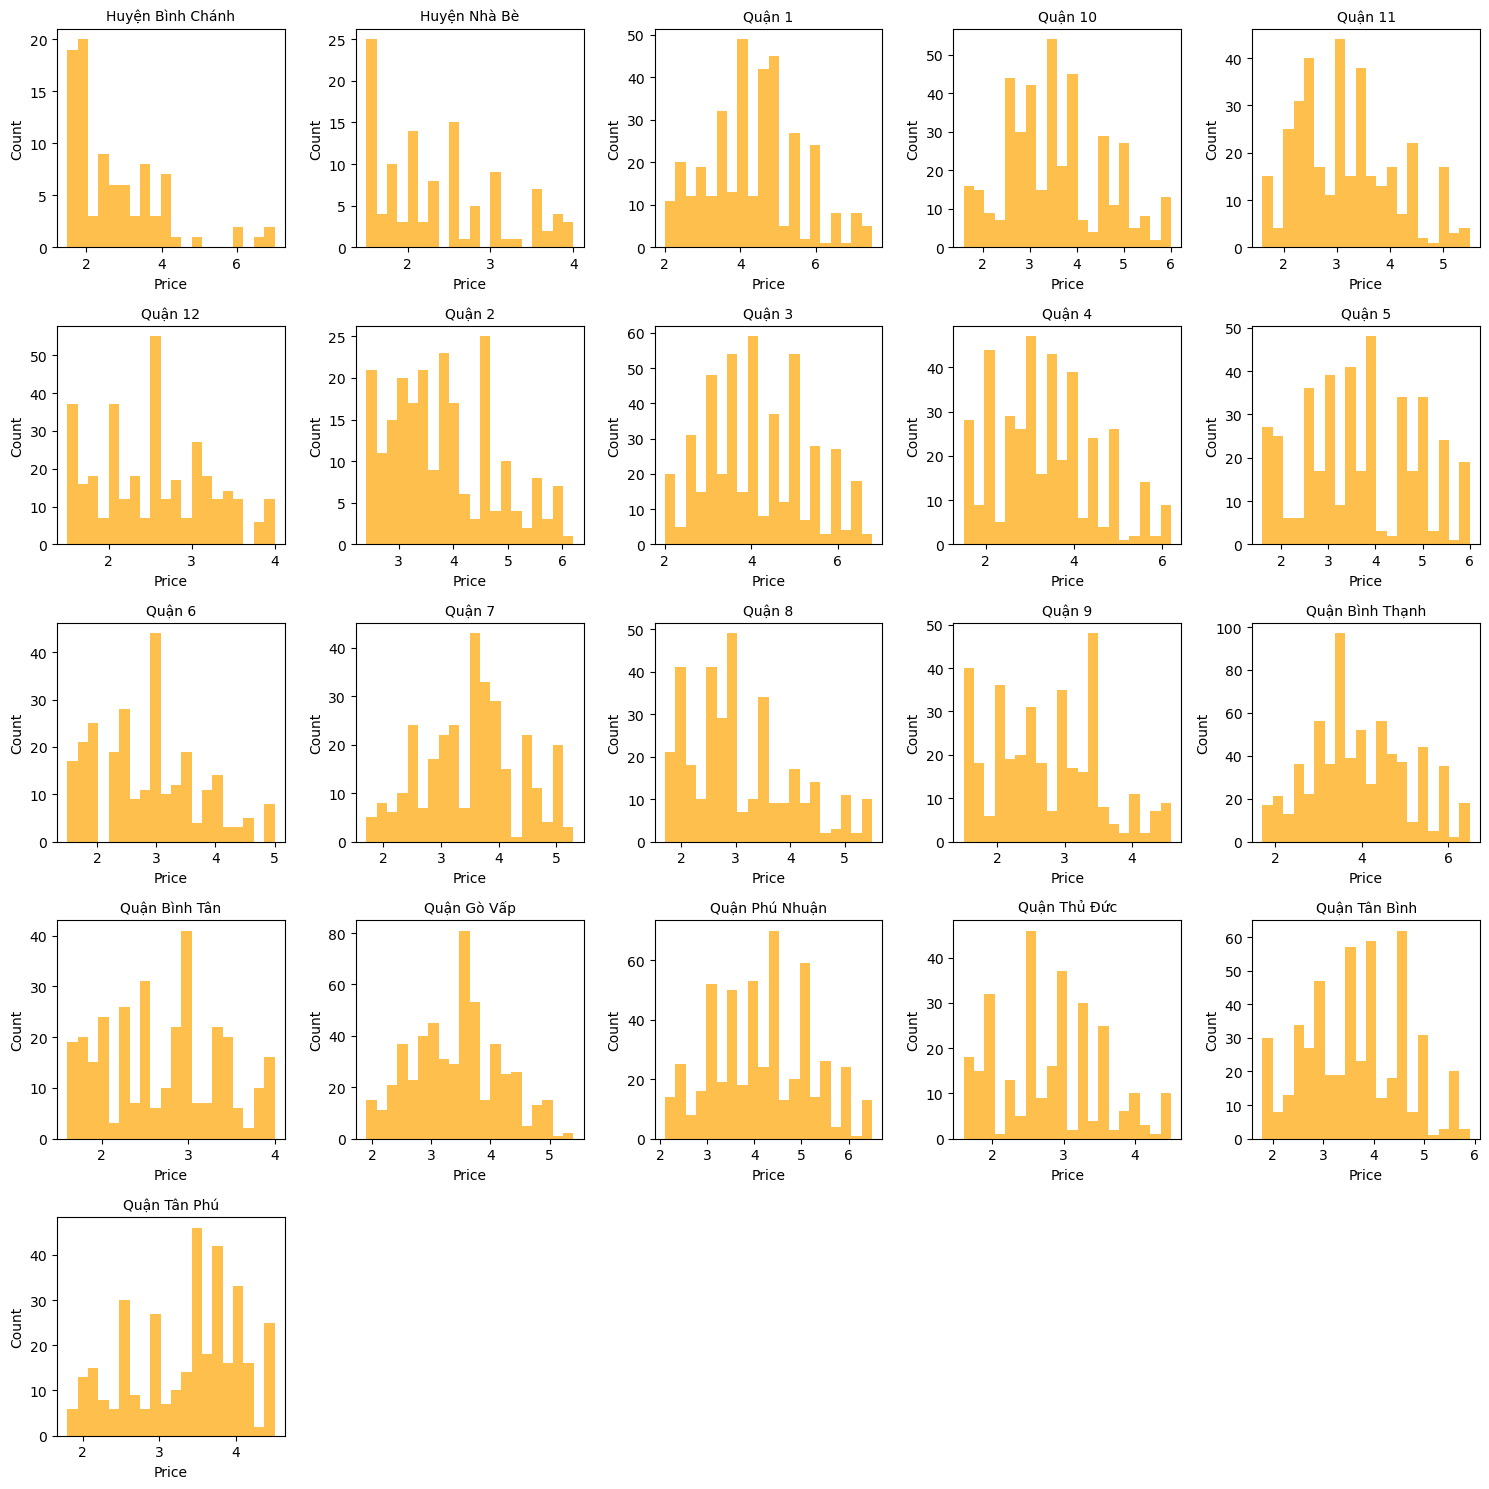

In [7]:
# Assuming df is already defined and contains 'district' and 'price'
unique_districts = sorted(df["district"].unique())
n_districts = len(unique_districts)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
axes = axes.flatten()

for idx, district in enumerate(unique_districts):
    ax = axes[idx]
    subset = df[df["district"] == district]
    ax.hist(subset["price"], bins=20, color="orange", alpha=0.7)
    ax.set_title(district, fontsize=10)
    ax.set_xlabel("Price")
    ax.set_ylabel("Count")

# Turn off any extra subplots
for idx in range(n_districts, 25):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

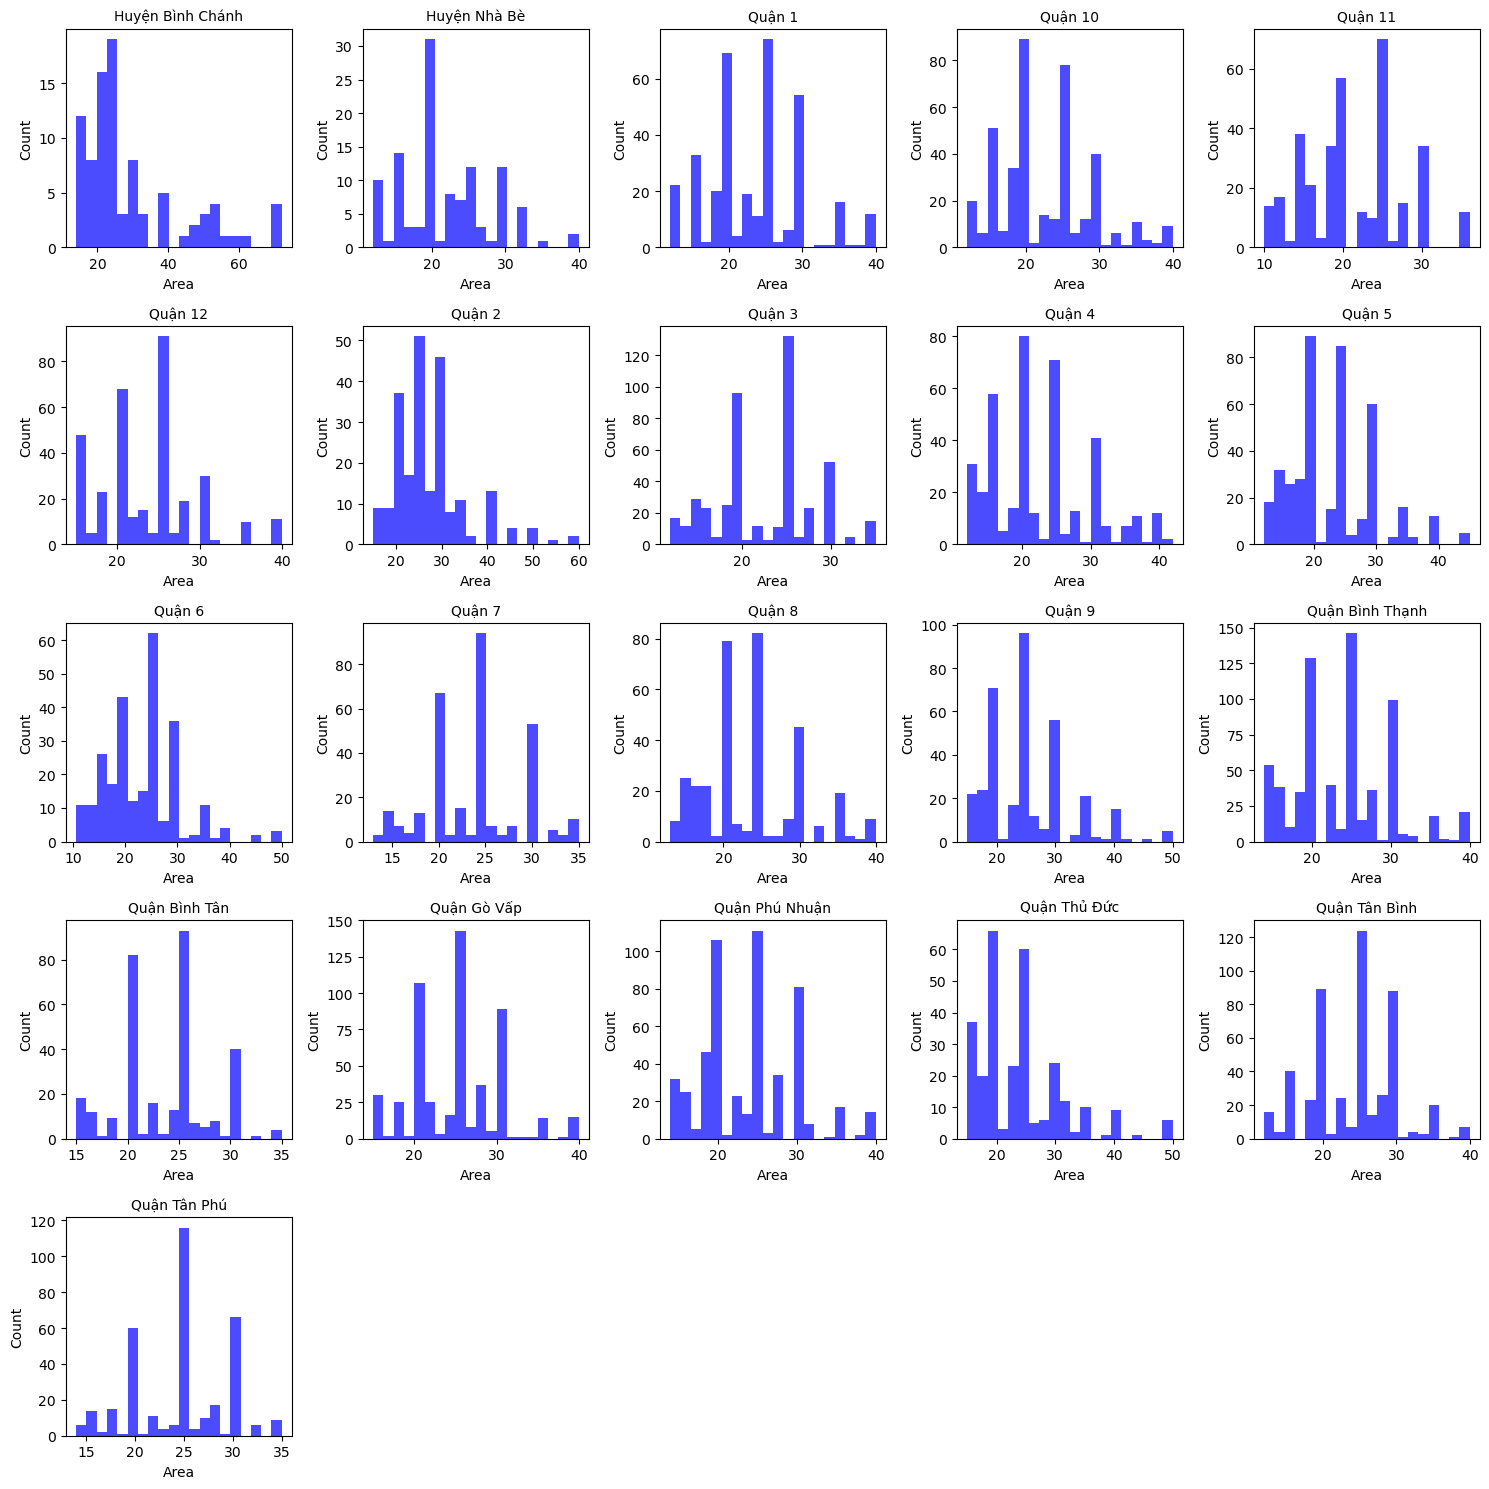

In [8]:
# Assuming df is already defined and contains 'district' and 'price'
unique_districts = sorted(df["district"].unique())
n_districts = len(unique_districts)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
axes = axes.flatten()

for idx, district in enumerate(unique_districts):
    ax = axes[idx]
    subset = df[df["district"] == district]
    ax.hist(subset["area"], bins=20, color="blue", alpha=0.7)
    ax.set_title(district, fontsize=10)
    ax.set_xlabel("Area")
    ax.set_ylabel("Count")

# Turn off any extra subplots
for idx in range(n_districts, 25):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

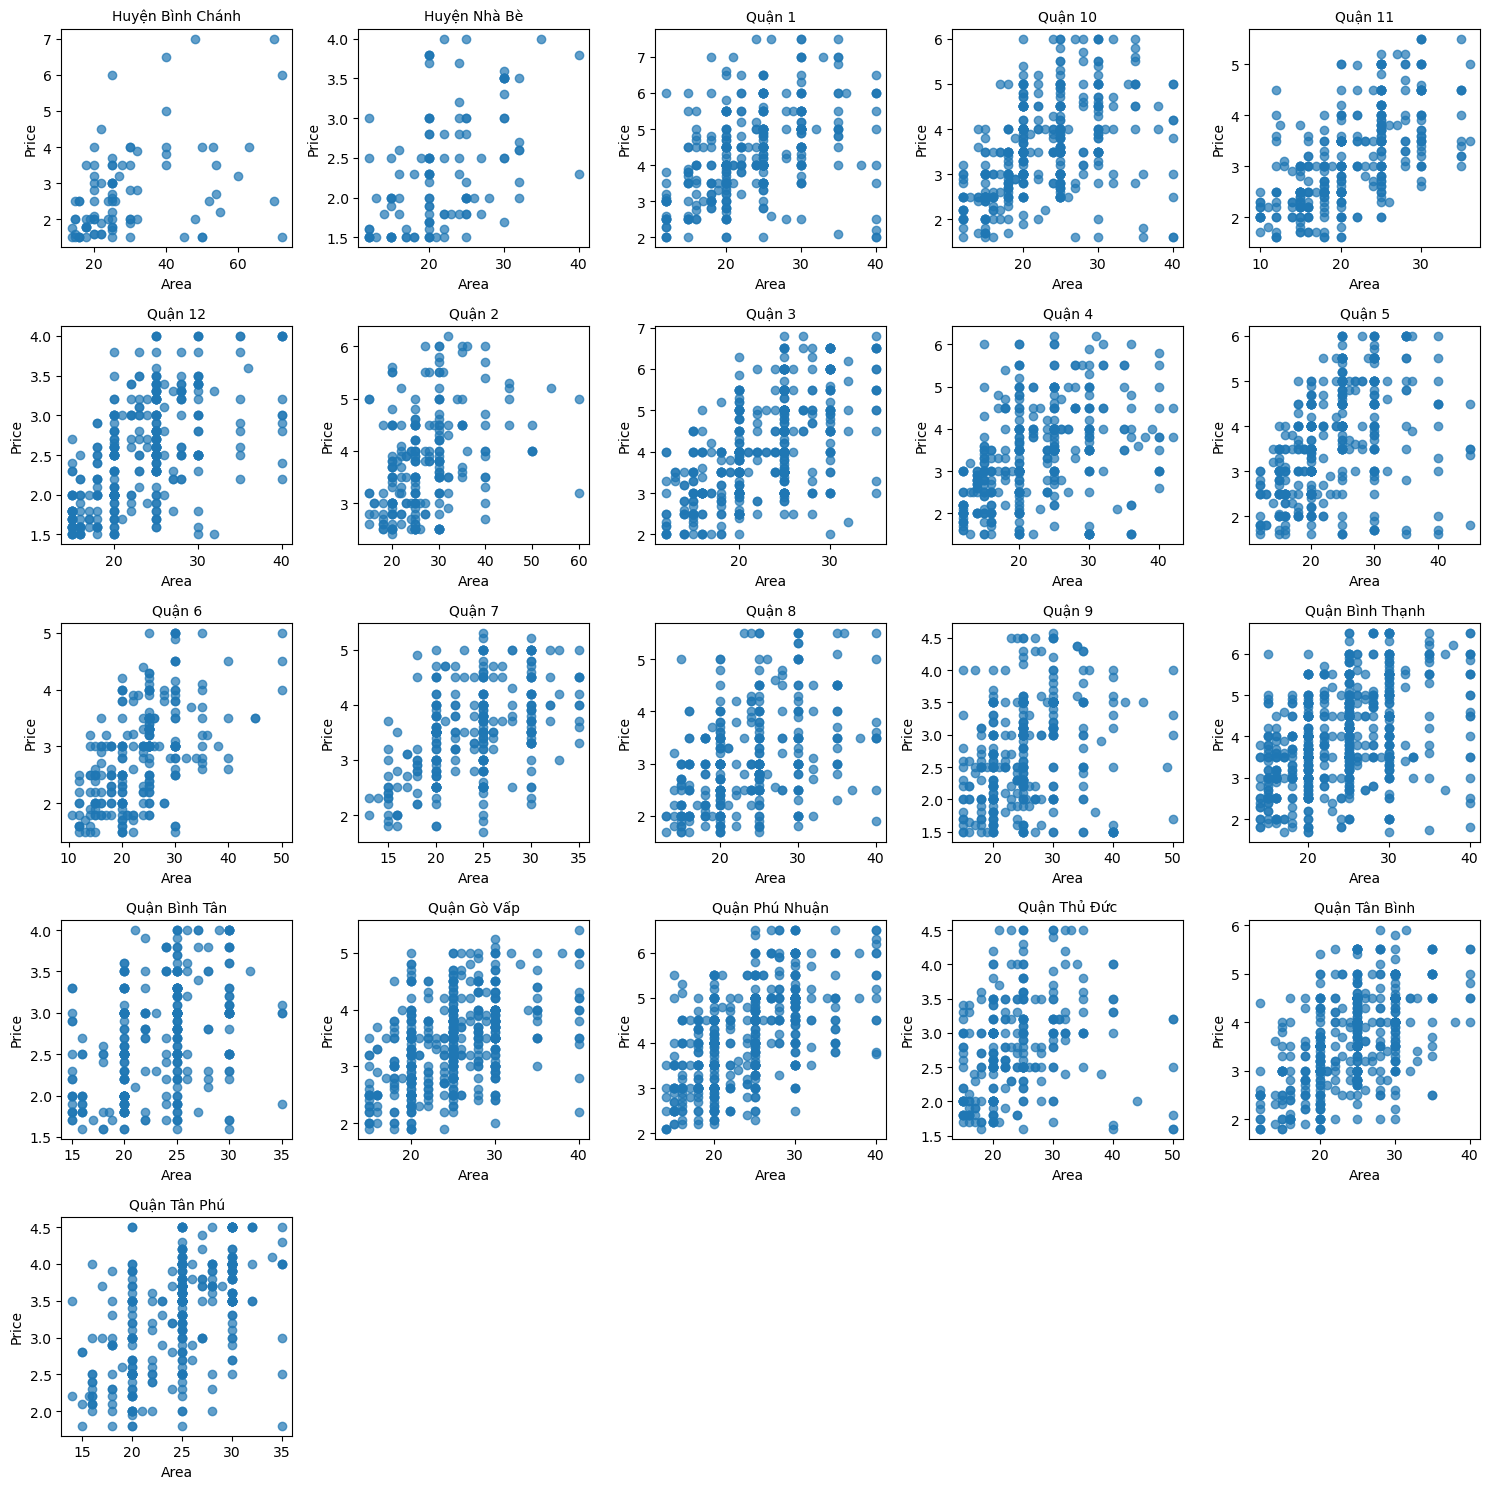

In [9]:
unique_districts = sorted(df["district"].unique())
n_districts = len(unique_districts)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
axes = axes.flatten()

for idx, district in enumerate(unique_districts):
    ax = axes[idx]
    subset = df[df["district"] == district]
    ax.scatter(subset["area"], subset["price"], alpha=0.7)
    ax.set_title(district, fontsize=10)
    ax.set_xlabel("Area")
    ax.set_ylabel("Price")

# Turn off any extra subplots
for idx in range(n_districts, 25):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

We propose the three models as follow:

**Model 1:**

\begin{align}
    \text{RP} = (\alpha + \sum \gamma_i \text{D}_i) + \beta \text{Area} 
\end{align}

In model 1: we allow the different in premium (Intercept + $\gamma$) in each district and assume the price/area coefficient (i.e. the $\beta$) is the same for each district


**Model 2:**

\begin{align}
    \text{RP} = \alpha + (\beta + \sum \gamma_i \text{D}_i) \text{Area}
\end{align}

In model 2: we assume the same premium (Intercept) for all district but the rate of price/area is different for each district


**Model 3:**
\begin{align}
    \text{RP} &= \alpha + (\beta + \sum \gamma_i \text{D}_i) \text{Area} + \sum \gamma_i \text{D}_i \\
    \text{RP} &= \alpha + \beta \text{Area} + \sum \gamma_i (\text{D}_i \cdot \text{Area})  + \sum \gamma_i \text{D}_i
\end{align}

Model 3 is the combination of both model 1 and model 2. In model 3, each district has a different premium which is the aggregation of unmeasured factors such as number of schools, hospitals, government services, distance to common workplaces, parks, etc. and the rate of price/area is different among districts

In [10]:
y, X = patsy.dmatrices('price ~ area + C(district)', data=df, return_type='dataframe')

model  = sm.OLS(y, X)
result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     226.1
Date:                Wed, 23 Jul 2025   Prob (F-statistic):               0.00
Time:                        16:24:33   Log-Likelihood:                -9666.1
No. Observations:                7566   AIC:                         1.938e+04
Df Residuals:                    7544   BIC:                         1.953e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [11]:
y, X = patsy.dmatrices('price ~ area + area:district', data=df, return_type='dataframe')

model  = sm.OLS(y, X)
result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     236.6
Date:                Wed, 23 Jul 2025   Prob (F-statistic):               0.00
Time:                        16:24:33   Log-Likelihood:                -9599.0
No. Observations:                7566   AIC:                         1.924e+04
Df Residuals:                    7544   BIC:                         1.939e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [12]:
y, X = patsy.dmatrices('price ~ area*district', data=df, return_type='dataframe')

model  = sm.OLS(y, X)
result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     125.4
Date:                Wed, 23 Jul 2025   Prob (F-statistic):               0.00
Time:                        16:24:33   Log-Likelihood:                -9542.5
No. Observations:                7566   AIC:                         1.917e+04
Df Residuals:                    7524   BIC:                         1.946e+04
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [13]:
agg_funcs = {
    'price': ['mean', 'median', 'std', 'min', 'max'],
    'area' : ['mean', 'median', 'std', 'min', 'max']
}

df.groupby('district').agg(agg_funcs)

price                              area                 \
                   mean median    std  min    max    mean median     std   
district                                                                   
Huyện Bình Chánh  2.752    2.5  1.256  1.5  7.000  29.824   25.0  14.825   
Huyện Nhà Bè      2.337    2.2  0.732  1.5  4.000  21.870   20.0   6.167   
Quận 1            4.339    4.2  1.228  2.0  7.500  23.509   24.0   6.609   
Quận 10           3.543    3.5  1.045  1.6  6.000  22.485   20.0   6.351   
Quận 11           3.164    3.0  0.935  1.6  5.500  21.227   20.0   6.095   
Quận 12           2.525    2.5  0.667  1.5  4.000  23.343   24.0   5.754   
Quận 2            3.798    3.7  0.954  2.4  6.200  27.377   25.0   7.949   
Quận 3            4.111    4.0  1.190  2.0  6.800  22.656   24.0   5.435   
Quận 4            3.357    3.3  1.140  1.5  6.200  22.345   20.0   7.208   
Quận 5            3.668    3.5  1.199  1.6  6.000  23.370   22.0   6.916   
Quận 6            2.855    2.9  0.852  1.5  5.000  23.531   24.0   7.098   
Quận 7            3.534    3.5  0.833  1.7  5.300  24.006   25.0   4.979   
Quận 8            3.082    3.0  0.954  1.7  5.500  23.616   24.0   6.302   
Quận 9            2.718    2.6  0.801  1.5  4.577  25.482   25.0   6.850   
Quận Bình Thạnh   3.965    3.8  1.144  1.7  6.500  23.831   25.0   6.027   
Quận Bình Tân     2.702    2.7  0.668  1.6  4.000  23.253   25.0   4.419   
Quận Gò Vấp       3.412    3.5  0.741  1.9  5.400  24.785   25.0   5.333   
Quận Phú Nhuận    4.160    4.2  1.043  2.1  6.500  23.927   25.0   5.897   
Quận Thủ Đức      2.797    2.8  0.725  1.6  4.500  24.094   22.0   7.242   
Quận Tân Bình     3.648    3.6  0.949  1.8  5.900  24.167   25.0   5.818   
Quận Tân Phú      3.334    3.5  0.713  1.8  4.500  24.638   25.0   4.583   

                              
                   min   max  
district                      
Huyện Bình Chánh  14.0  72.0  
Huyện Nhà Bè      12.0  40.0  
Quận 1            12.0  40.0  
Quận 10           12.0  40.0  
Quận 11           10.0  36.0  
Quận 12           15.0  40.0  
Quận 2            15.0  60.0  
Quận 3            12.0  35.0  
Quận 4            12.0  42.0  
Quận 5            12.0  45.0  
Quận 6            10.6  50.0  
Quận 7            13.0  35.0  
Quận 8            13.0  40.0  
Quận 9            15.0  50.0  
Quận Bình Thạnh   14.0  40.0  
Quận Bình Tân     15.0  35.0  
Quận Gò Vấp       15.0  40.0  
Quận Phú Nhuận    14.0  40.0  
Quận Thủ Đức      15.0  50.0  
Quận Tân Bình     12.0  40.0  
Quận Tân Phú      14.0  35.0

In [14]:
import scipy.stats as stats
from scipy.stats import f_oneway
groups = [group['ppa'].values for name, group in df.groupby('district') if len(group['ppa'].dropna()) > 1]
if len(groups) >= 2:
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_value:.3f}")
else:
    print("Not enough valid groups for ANOVA.")

ANOVA F-statistic: 132.065, p-value: 0.000


In [15]:
confidence_level = 0.95
ci_results = []

for name, group in df.groupby('district'):
    ppa_values = group['ppa'].dropna().values
    n = len(ppa_values)
    if n < 2:
        continue  # Skip groups with too few values

    mean = np.mean(ppa_values)
    sem = stats.sem(ppa_values)  # Standard error of the mean
    h = sem * stats.t.ppf((1 + confidence_level) / 2., n - 1)  # Margin of error

    ci_results.append((name, mean, mean - h, mean + h))

# Convert to DataFrame for better viewing
ci_df = pd.DataFrame(ci_results, columns=['district', 'mean_ppa', 'ci_lower', 'ci_upper'])
print(ci_df)

            district  mean_ppa  ci_lower  ci_upper
0   Huyện Bình Chánh     0.103     0.094     0.111
1       Huyện Nhà Bè     0.111     0.105     0.117
2             Quận 1     0.193     0.187     0.199
3            Quận 10     0.163     0.159     0.168
4            Quận 11     0.154     0.150     0.159
5            Quận 12     0.110     0.108     0.113
6             Quận 2     0.146     0.140     0.151
7             Quận 3     0.185     0.181     0.189
8             Quận 4     0.158     0.153     0.163
9             Quận 5     0.162     0.158     0.167
10            Quận 6     0.126     0.122     0.130
11            Quận 7     0.150     0.146     0.154
12            Quận 8     0.135     0.131     0.139
13            Quận 9     0.111     0.108     0.115
14   Quận Bình Thạnh     0.171     0.168     0.175
15     Quận Bình Tân     0.118     0.115     0.121
16       Quận Gò Vấp     0.141     0.138     0.144
17    Quận Phú Nhuận     0.178     0.174     0.182
18      Quận Thủ Đức     0.122 

Shapiro-Wilk Normality Test:
Huyện Bình Chánh: W=0.975, p-value=0.082 -> Normal
Huyện Nhà Bè: W=0.929, p-value=0.000 -> Not Normal
Quận 1: W=0.951, p-value=0.000 -> Not Normal
Quận 10: W=0.993, p-value=0.064 -> Normal
Quận 11: W=0.939, p-value=0.000 -> Not Normal
Quận 12: W=0.994, p-value=0.186 -> Normal
Quận 2: W=0.941, p-value=0.000 -> Not Normal
Quận 3: W=0.989, p-value=0.002 -> Not Normal
Quận 4: W=0.984, p-value=0.000 -> Not Normal
Quận 5: W=0.990, p-value=0.006 -> Not Normal
Quận 6: W=0.982, p-value=0.002 -> Not Normal
Quận 7: W=0.989, p-value=0.019 -> Not Normal
Quận 8: W=0.966, p-value=0.000 -> Not Normal
Quận 9: W=0.984, p-value=0.000 -> Not Normal
Quận Bình Thạnh: W=0.990, p-value=0.000 -> Not Normal
Quận Bình Tân: W=0.984, p-value=0.001 -> Not Normal
Quận Gò Vấp: W=0.976, p-value=0.000 -> Not Normal
Quận Phú Nhuận: W=0.976, p-value=0.000 -> Not Normal
Quận Thủ Đức: W=0.979, p-value=0.000 -> Not Normal
Quận Tân Bình: W=0.971, p-value=0.000 -> Not Normal
Quận Tân Phú: W=0.975,

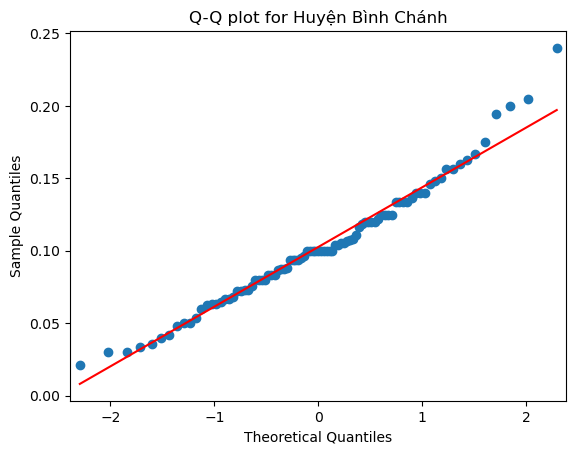

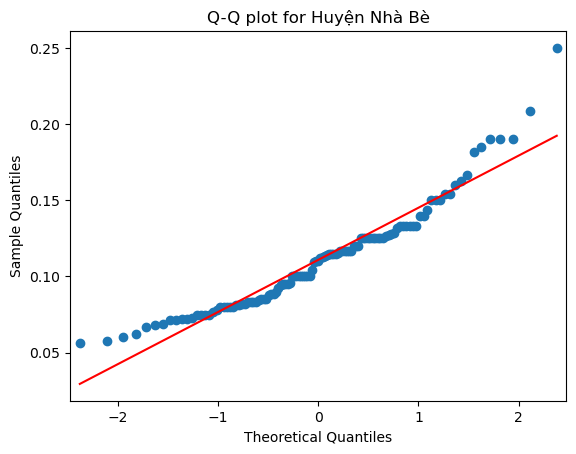

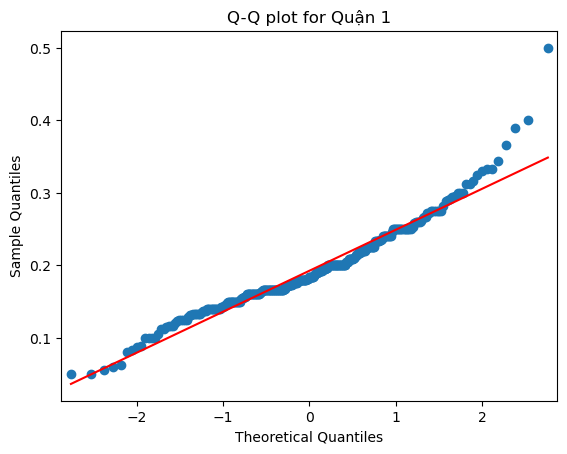

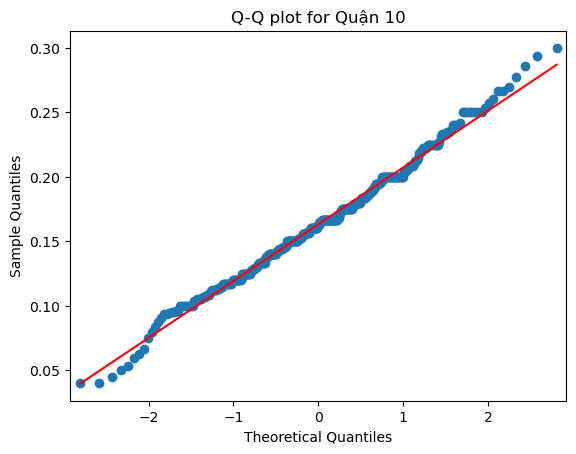

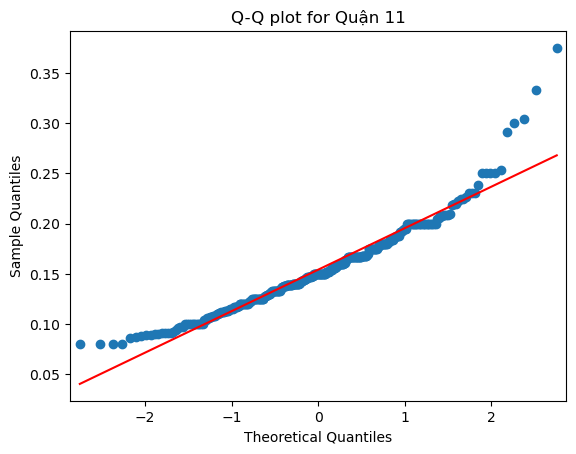

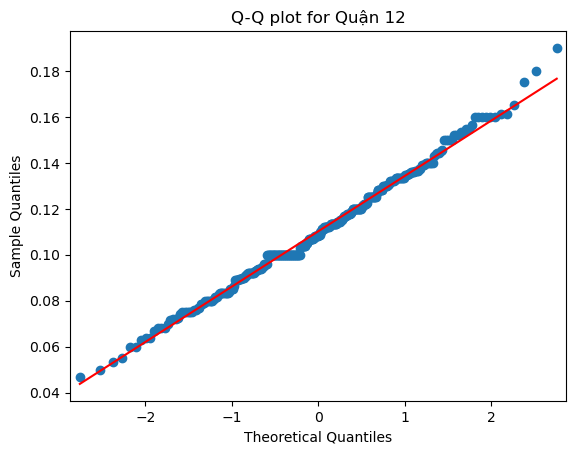

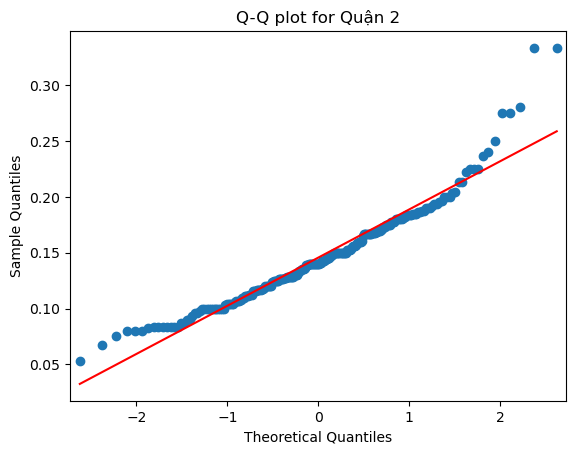

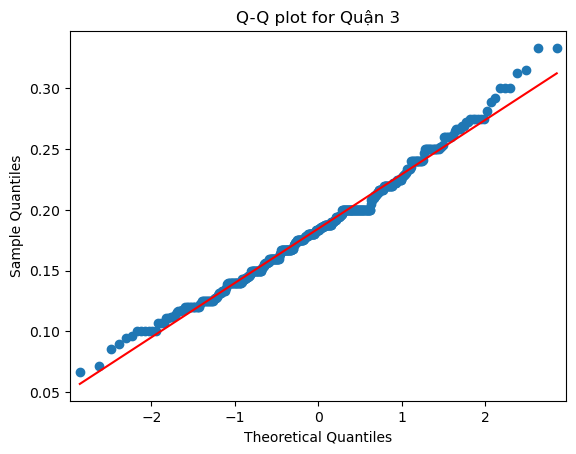

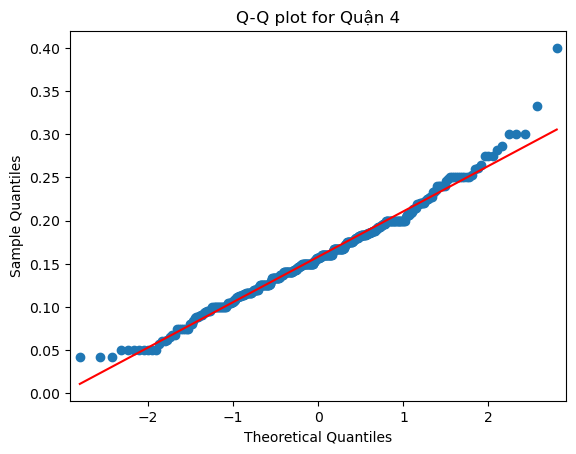

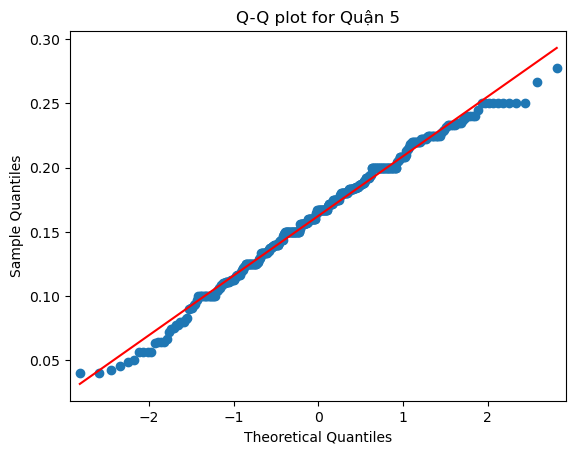

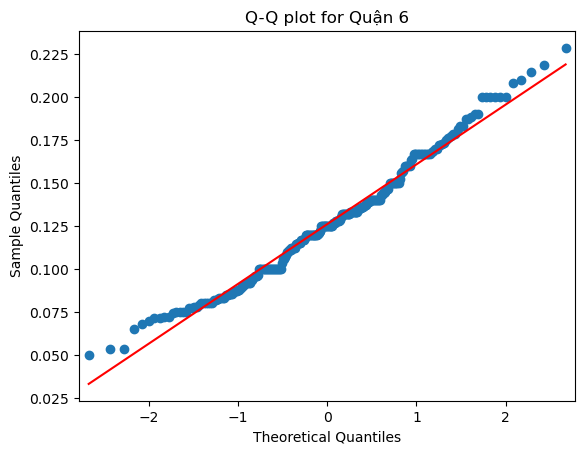

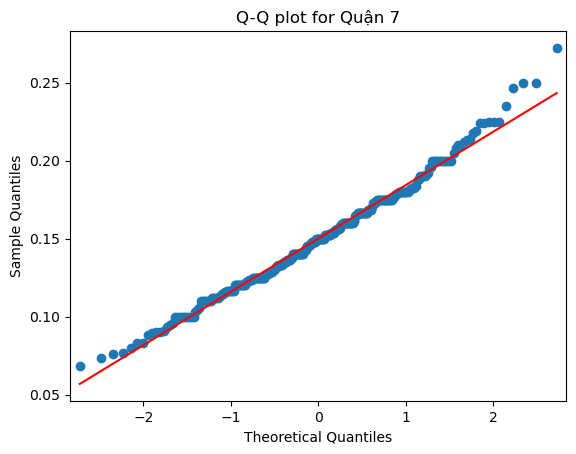

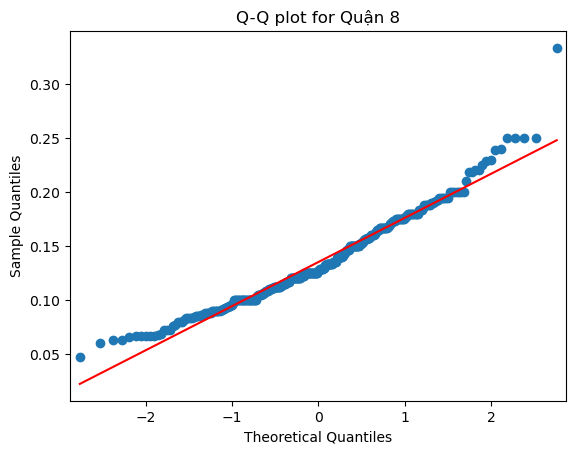

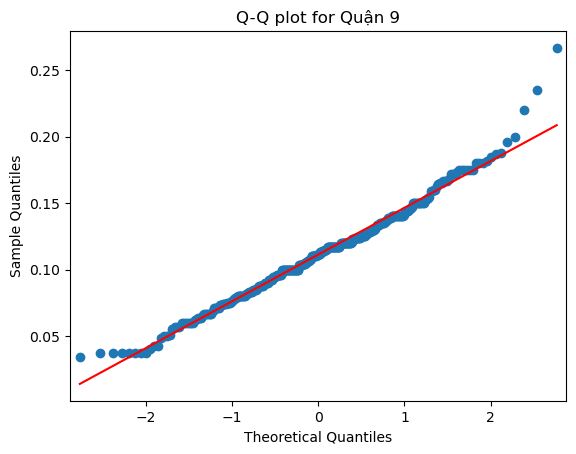

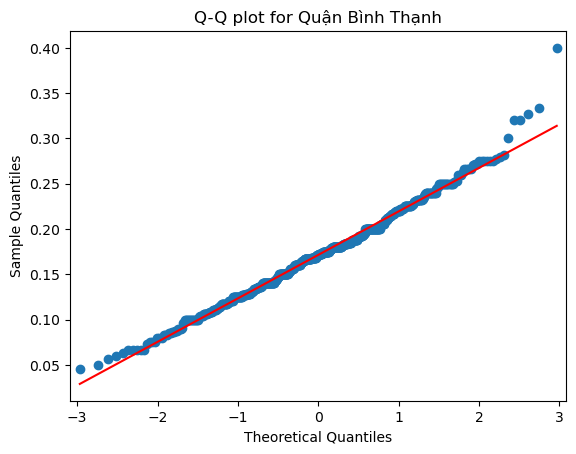

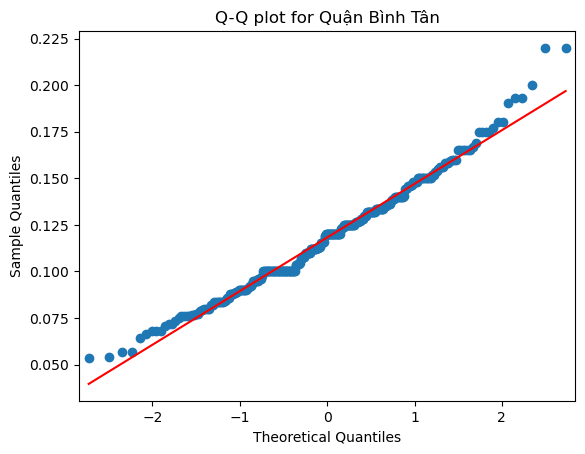

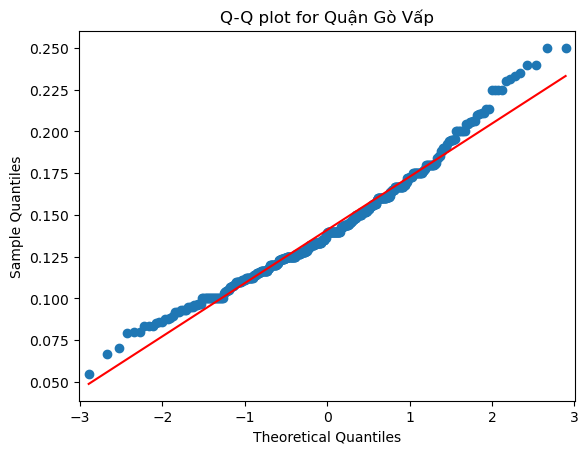

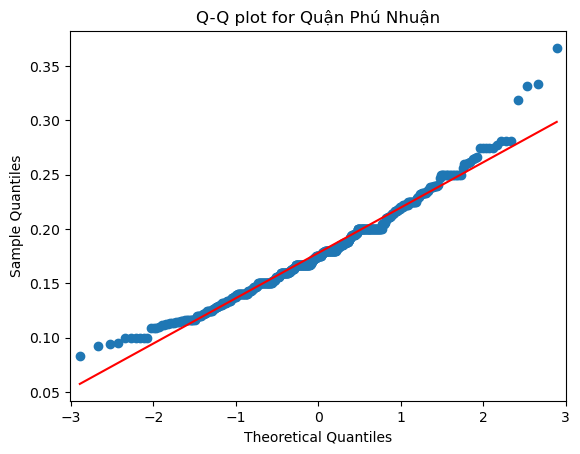

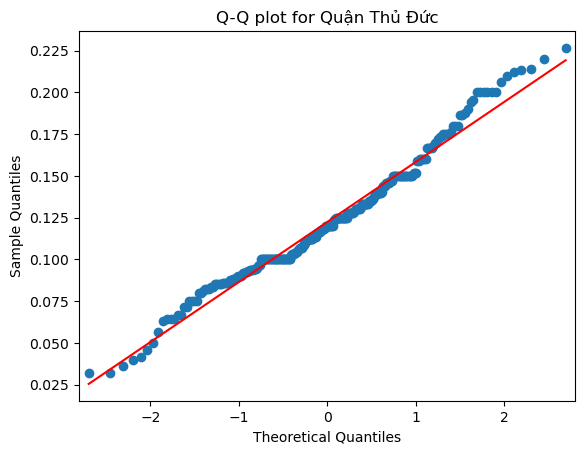

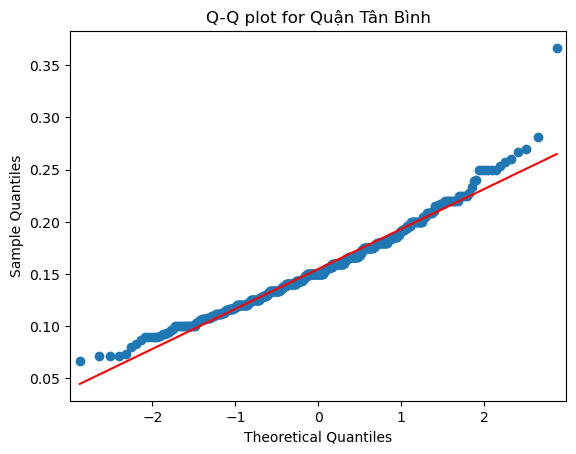

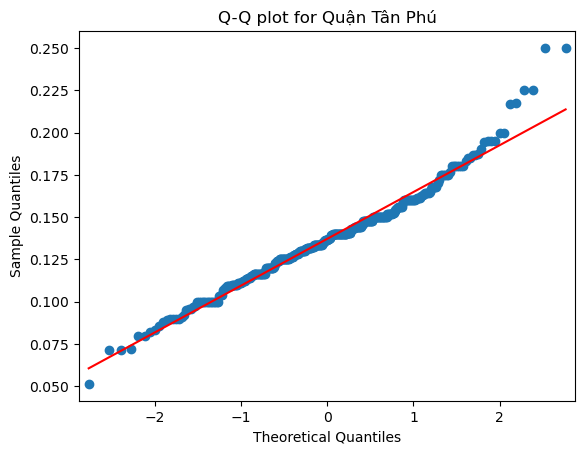


Levene’s test: W=20.592, p-value=0.000 -> Unequal variances


In [16]:
print("Shapiro-Wilk Normality Test:")
for name, group in df.groupby('district'):
    ppa_values = group['ppa'].dropna()
    if len(ppa_values) >= 3:
        stat, p = stats.shapiro(ppa_values)
        print(f"{name}: W={stat:.3f}, p-value={p:.3f} -> {'Normal' if p > 0.05 else 'Not Normal'}")
for name, group in df.groupby('district'):
    if len(group['ppa']) >= 3:
        sm.qqplot(group['ppa'], line='s')
        plt.title(f"Q-Q plot for {name}")
        plt.show()
grouped = [group['ppa'].dropna() for _, group in df.groupby('district') if len(group) >= 3]
levene_stat, levene_p = stats.levene(*grouped)
print(f"\nLevene’s test: W={levene_stat:.3f}, p-value={levene_p:.3f} -> {'Equal variances' if levene_p > 0.05 else 'Unequal variances'}")

In [17]:
from scipy.stats import kruskal

groups = [group['ppa'].dropna() for _, group in df.groupby('district')]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis test: H={stat:.3f}, p-value={p:.3f}")


Kruskal-Wallis test: H=2112.672, p-value=0.000


DataFrame head:
                                               title  price   published  area  \
0  Cho thuê nhà trọ mới sạch đẹp tại Lê Đình Cẩn,...    2.2  16/05/2022  20.0   
1  Cho thuê phòng trọ giá rẻ ở mặt tiền hẻm lớn Đ...    2.5  20/04/2022  20.0   
2  Cho thuê phòng trọ kdc Nam Long-Trần Trọng Cun...    3.5   10/5/2022  30.0   
4  Cho thuê phòng có gác, không gác, tolet riêng ...    3.5    5/1/2022  18.0   
5  Phòng cho thuê dành cho người đi làm, gần nhiề...    2.2   5/11/2020  15.0   

                          address        district          city    ppa  \
0                     Lê Đình Cẩn   Quận Bình Tân   Hồ Chí Minh  0.110   
1  487/35/25 Đường Huỳnh Tấn Phát          Quận 7   Hồ Chí Minh  0.125   
2                        Đường 10          Quận 7   Hồ Chí Minh  0.117   
4                       Lê Văn Sỹ  Quận Phú Nhuận   Hồ Chí Minh  0.194   
5       174/15 Đường Đặng Văn Ngữ  Quận Phú Nhuận   Hồ Chí Minh  0.147   

   price95  price05  area95  area05  
0     4.00    

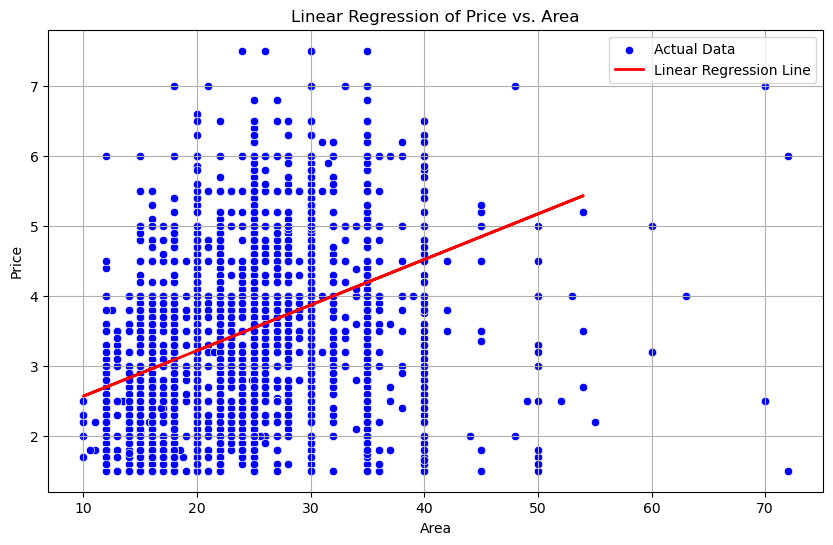


Intercept: 1.91
Coefficient for Area: 0.07

Statsmodels Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     1306.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):          5.67e-264
Time:                        16:24:37   Log-Likelihood:                -10910.
No. Observations:                7566   AIC:                         2.182e+04
Df Residuals:                    7564   BIC:                         2.184e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
# Display the first few rows and column names to confirm structure
print("DataFrame head:")
print(df.head())
print("\nDataFrame columns:")
print(df.columns)

# Define independent variable (X) and dependent variable (Y)
# Assuming 'area' as independent variable and 'price' as dependent variable for linear regression.
# You can change these if needed.
X = df[['area']]  # Independent variable (features)
y = df['price']   # Dependent variable (target)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Plotting the linear regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=df, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linear Regression Line')
plt.title('Linear Regression of Price vs. Area')
plt.xlabel('Area')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Print the model coefficients
print(f"\nIntercept: {model.intercept_:.2f}")
print(f"Coefficient for Area: {model.coef_[0]:.2f}")

# You can also use statsmodels for a more detailed summary
# Add a constant to the independent variable for statsmodels
X_sm = sm.add_constant(X)

# Create and fit the OLS model
model_sm = sm.OLS(y, X_sm).fit()

# Print the summary of the regression
print("\nStatsmodels Regression Summary:")
print(model_sm.summary())


Average Price per District (Sorted by Price):
district
Quận 1              4.339
Quận Phú Nhuận      4.160
Quận 3              4.111
Quận Bình Thạnh     3.965
Quận 2              3.798
Quận 5              3.668
Quận Tân Bình       3.648
Quận 10             3.543
Quận 7              3.534
Quận Gò Vấp         3.412
Quận 4              3.357
Quận Tân Phú        3.334
Quận 11             3.164
Quận 8              3.082
Quận 6              2.855
Quận Thủ Đức        2.797
Huyện Bình Chánh    2.752
Quận 9              2.718
Quận Bình Tân       2.702
Quận 12             2.525
Huyện Nhà Bè        2.337
Name: price, dtype: float64


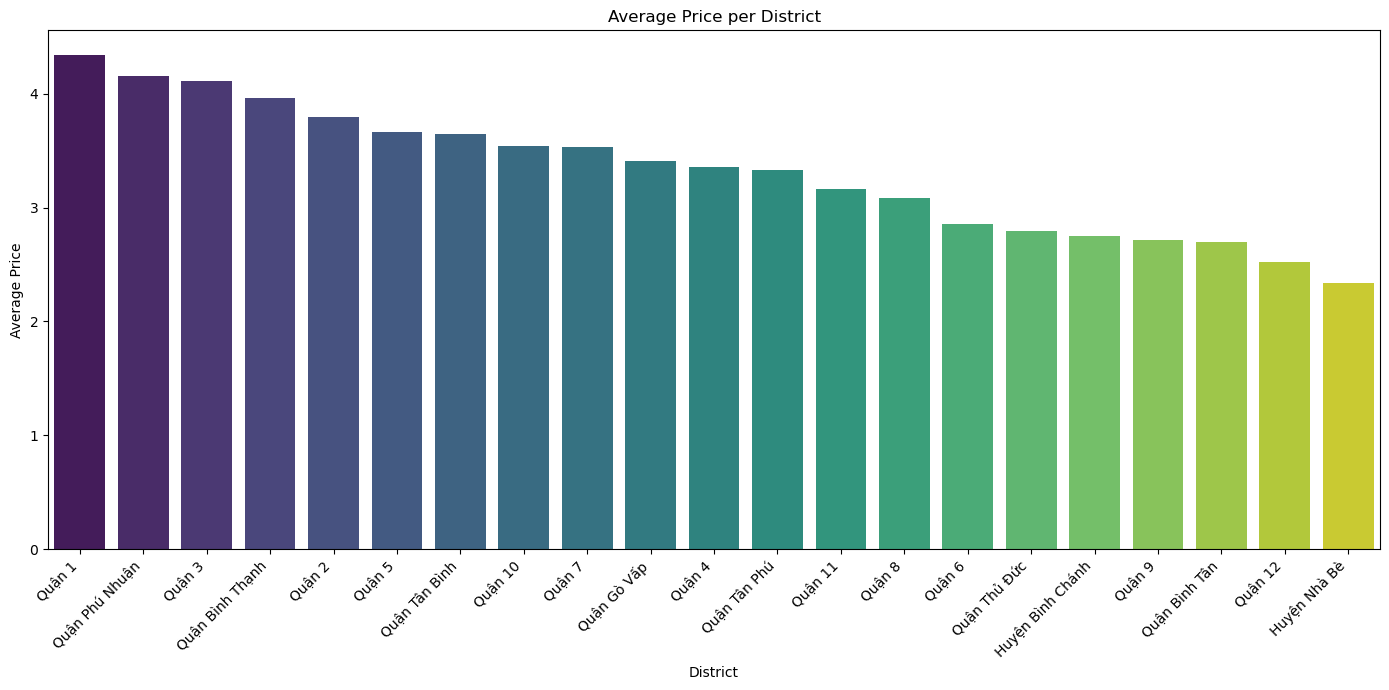


ANOVA Table for Price by District:
               sum_sq      df        F  PR(>F)
C(district)  2135.060    20.0  112.547     0.0
Residual     7156.558  7545.0      NaN     NaN

--- Interpretation of Results ---
1. Average Price per District:
   - The bar plot and the printed table show the average price for each district.
   - Districts with higher average prices can be considered 'more important' in terms of driving up housing costs.
   - For example, if 'Quận 1' has a much higher average price, it indicates it's a more expensive and thus 'important' district for pricing.

2. ANOVA Test:
   - Look at the 'PR(>F)' value in the ANOVA table for 'C(district)'.
   - If 'PR(>F)' (p-value) is less than 0.05 (a common significance level), it indicates that there is a statistically significant difference in the mean prices across at least some of the districts.
   - A very low p-value (e.g., close to 0) suggests that district is a very important factor in explaining the variation in housing p

In [19]:
# --- 1. Average Price per District ---

# Calculate the mean price for each district
mean_price_per_district = df.groupby('district', observed=True)['price'].mean().sort_values(ascending=False)

print("Average Price per District (Sorted by Price):")
print(mean_price_per_district)

# Visualize the average price per district
plt.figure(figsize=(14, 7))
sns.barplot(x=mean_price_per_district.index, y=mean_price_per_district.values, hue=mean_price_per_district.index, palette='viridis', legend=False)
plt.title('Average Price per District')
plt.xlabel('District')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right') # Rotate district names for better readability
plt.tight_layout()
plt.show()

# --- 2. ANOVA (Analysis of Variance) Test ---
# ANOVA tests if there are statistically significant differences between the means of two or more groups.
# Here, it tests if there's a significant difference in 'price' across different 'district' groups.

# Ensure 'district' is treated as a categorical variable for ANOVA
df['district'] = df['district'].astype('category')

# Perform one-way ANOVA
# The formula 'price ~ C(district)' specifies price as the dependent variable
# and district as the categorical independent variable.
model_anova = ols('price ~ C(district)', data=df).fit()

# Print the ANOVA table
anova_table = sm.stats.anova_lm(model_anova, typ=2) # Type 2 ANOVA is suitable for unbalanced designs
print("\nANOVA Table for Price by District:")
print(anova_table)

print("\n--- Interpretation of Results ---")
print("1. Average Price per District:")
print("   - The bar plot and the printed table show the average price for each district.")
print("   - Districts with higher average prices can be considered 'more important' in terms of driving up housing costs.")
print("   - For example, if 'Quận 1' has a much higher average price, it indicates it's a more expensive and thus 'important' district for pricing.")

print("\n2. ANOVA Test:")
print("   - Look at the 'PR(>F)' value in the ANOVA table for 'C(district)'.")
print("   - If 'PR(>F)' (p-value) is less than 0.05 (a common significance level), it indicates that there is a statistically significant difference in the mean prices across at least some of the districts.")
print("   - A very low p-value (e.g., close to 0) suggests that district is a very important factor in explaining the variation in housing prices.")

print("\nNote on 'Importance':")
print("For categorical variables like 'district', 'importance' isn't typically measured as a single numerical score like feature importance in tree models.")
print("Instead, we look at the magnitude of differences in mean prices and the statistical significance of those differences (via ANOVA or regression coefficients' p-values).")
print("The districts with higher average prices or statistically significant coefficients compared to a baseline are the 'important' ones in determining price.")